<a href="https://colab.research.google.com/github/jubayer27/AI_Project/blob/main/pytorch_digit_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import torch
import torch.nn as nn # for building the model
import torch.nn.functional as F
import torchvision # for datasets and transformations
import torchvision.transforms as transforms #for processing the data. in machine learning , raw data is not suitable for training a model. we need to process it and make it suitable for training by making it in a form of tensors and normalizing it.
import torch.optim as optim


transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True
)

#printing the shape of the data

dataiter = iter(trainloader)
images, lables =next(dataiter)
print(images.shape)
print(lables)

torch.Size([32, 1, 28, 28])
tensor([9, 0, 5, 2, 8, 2, 5, 5, 1, 0, 6, 8, 4, 1, 0, 8, 3, 2, 2, 8, 1, 8, 7, 7,
        8, 6, 3, 2, 1, 2, 0, 4])


In [32]:


class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


net = Net()


In [33]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [34]:
for epoch in range(3):  # 3 times full dataset

    running_loss = 0.0

    for images, labels in trainloader:

        optimizer.zero_grad()        # clear old gradients

        outputs = net(images)        # forward pass
        loss = criterion(outputs, labels)

        loss.backward()              # backpropagation
        optimizer.step()             # update weights

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

Epoch 1, Loss: 426.547
Epoch 2, Loss: 134.335
Epoch 3, Loss: 102.092


In [35]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in trainloader:
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 98.69%


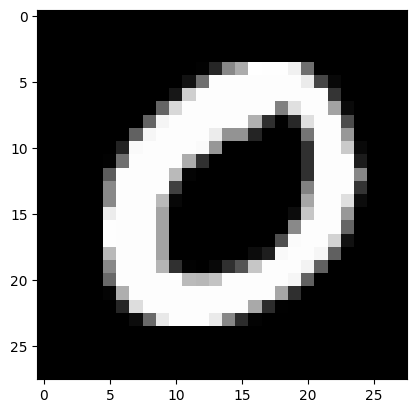

Predicted: 0


In [36]:
import matplotlib.pyplot as plt

img = images[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.show()

output = net(img.unsqueeze(0))
_, pred = torch.max(output, 1)

print("Predicted:", pred.item())